# reff trace: observations, actions, rewards + (reward - expected reward) + forecast

Analog of `value_bootstrap_trace` for a network trained with `train_treadmill_agent_jax_reff_pg.py`.
Auto-loads the **newest** trajectory pickle and plots, on a shared time axis: the raw observations /
actions / rewards; `E[r]` (the actor's expected reward); `r - E[r]` and the reff_pg "luck" trace
(reset-at-reward, timescale = the script's `MOD_TAU`); and the **multi-timestep forecast**
`r_hat[t, j] = E[r_{t+j} | state_t]` for lags `j = 0..RPE_H` as a heatmap.

The forecast `r_hat` is read straight from the trajectory (`reward_pred`, now an extra `network.apply`
output cached during the rollout) -- **no checkpoint reload**. Pickles saved before that change fall
back to recomputing `predict_reward(actor_hidden)` from `checkpoint_0`.

In [33]:
import os
# Force CPU before any jax import (the GPU is often full).
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import sys, glob, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))          # code/  (agents, environments, ...)

## Model / trajectory

Point `EXP` at the reff run. The loader grabs the **most recent** trajectory pickle in its directory
(a training snapshot `trajectories/traj_*.pkl` or an eval dump `trajectories_*.pkl`) -- no path to edit.

In [45]:
REPO = Path.cwd()
while not (REPO / 'results').exists() and REPO != REPO.parent:
    REPO = REPO.parent

EXP      = 'reff_pg_exp_gru_initial_prob_offset_no_belief'   # <- set to your run
# EXP      = 'reff_pg_exp_gru_initial_prob_offset_belief_cleanl++++'   # <- set to your run

# EXP = 'reff_pg_markov_persistence_longer_interpatch'   # <- set to your run
# EXP = 'reff_pg_rpe_trace_exp_gru_initial_prob_offset'
TRAJ_IDX = 0                                          # which saved env / episode

cands = (glob.glob(str(REPO / 'results' / EXP / 'trajectories' / '*.pkl'))
         + glob.glob(str(REPO / 'results' / EXP / 'trajectories*.pkl')))
assert cands, f'no trajectory pickle under results/{EXP}/ (has the run saved a snapshot yet?)'
TRAJ_PATH = max(cands, key=os.path.getmtime)          # most recent by mtime
print('repo:', REPO)
print('newest trajectory:', os.path.relpath(TRAJ_PATH, REPO))

repo: /home/david.bell/work/favorably_connected_2
newest trajectory: results/reff_pg_exp_gru_initial_prob_offset_no_belief/trajectories_20260901_211448.pkl


In [46]:
with open(TRAJ_PATH, 'rb') as f:
    traj = pickle.load(f)
d = traj[TRAJ_IDX] if isinstance(traj, list) else traj

obs_full     = np.asarray(d['observations'])             # (T, obs+act+1)
OBS          = obs_full.shape[1] - 3                     # minus action_onehot(2) + prev_reward(1)
obs          = obs_full[:, :OBS]                         # (T, OBS)  sensory part
actions      = np.asarray(d['actions'])                 # (T,)
rewards      = np.asarray(d['rewards'])                 # (T,)
actor_hidden = np.asarray(d['actor_hidden'])            # (T, HID)  fallback reward-predictor input
rho          = np.asarray(d['exp_filtered_reward_rate']) if 'exp_filtered_reward_rate' in d else None  # (T,)
V            = np.asarray(d['values'])                  # (T,)  critic value V_t
belief       = np.asarray(d['belief']) if 'belief' in d and d['belief'] is not None else None  # (T, HID)
# cached quantities, if this pickle has them (reff_pg now stores them on the trajectory)
reward_pred_cached = np.asarray(d['reward_pred']) if 'reward_pred' in d and d['reward_pred'] is not None else None
belief_pred_cached = np.asarray(d['belief_pred']) if 'belief_pred' in d and d['belief_pred'] is not None else None
M_cached           = np.asarray(d['M'])           if 'M'           in d and d['M']           is not None else None
T = rewards.shape[0]
print(f'T = {T} | OBS = {OBS} | reward frac>0 = {(rewards > 0).mean():.4f}'
      f" | belief_pred: {'yes' if belief_pred_cached is not None else ('reward_pred' if reward_pred_cached is not None else 'no')}"
      f" | cached M: {'yes' if M_cached is not None else 'no (recompute)'}"
      f" | belief: {'yes' if belief is not None else 'no'}")

T = 20000 | OBS = 4 | reward frac>0 = 0.0544 | belief_pred: yes | cached M: yes | belief: yes


## Compute E[r], (r - E[r]), and the reff_pg modulation M

`r_hat[t, j] = E[r_{t+j} | state_t]` is the actor's forecast; `E[r_t]` is its lag-0 column (cached
`trajectory.reward_pred`, else recomputed from `checkpoint_0`). The modulation the loss actually
applies is **`M(t) = 1 - sum_{k=t'}^{t} E[r_k | o_{k-1}]`** where `t'` is the previous reward: the
lag-0 forecast accumulated since the last reward, **reset at each reward**. `M` starts near 1 after a
reward and falls, going **negative once the agent is "overdue"** (cumulative expected reward since the
last reward exceeds 1) -- overdue staying actions then earn negative reward credit. Read from the
cached `trajectory.M` when present, else recomputed with the same recurrence.

In [48]:
HID, ACT, RNN = actor_hidden.shape[1], 2, 'GRU'
GAMMA, M_DECAY, M_SCALE, RHO_WEIGHT, K_BOOT, N_BELIEF_PREDICT = 0.95, 0.99, 0.5, 0.0, 20, 20   # match the script

# reward forecast r_hat[t, j] = E[r_{t+j}]. reff_pg sources it from the belief's reward channels
# (belief_pred: obs+1 per lag, reward = last channel); older pickles have the actor reward_pred head.
if belief_pred_cached is not None:
    r_hat = belief_pred_cached.reshape(T, N_BELIEF_PREDICT, OBS + 1)[:, :, OBS]   # (T, NB)  belief reward channels
    print(f'using belief_pred reward channels {r_hat.shape}')
elif reward_pred_cached is not None:
    r_hat = reward_pred_cached                                                    # (T, RPE_H+1)  old actor head
    print(f'using cached reward_pred {r_hat.shape}')
else:
    raise RuntimeError('pickle has neither belief_pred nor reward_pred')

exp_reward = r_hat[:, 0]                                                       # (T,)  E[r_t] (lag 0)
innov = rewards - exp_reward                                                  # (T,)  reward - expected reward

# M: prefer the cached trajectory.M (includes the S_C belief gating); else a rough scalar fallback.
if M_cached is not None:
    M = M_cached
    print('using cached trajectory.M (no recompute)')
else:
    M = np.zeros(T); cumrp = 0.0
    for tt in range(T):
        M[tt] = 1.0 - M_SCALE * cumrp
        contrib = exp_reward[tt] + RHO_WEIGHT * (rho[tt] if rho is not None else 0.0)
        cumrp = contrib + (0.0 if rewards[tt] > 0 else M_DECAY * cumrp)

# --- k-step VALUE-BOOTSTRAP advantage: A_t = M_t*G_t + gamma^K V_{t+K} - V_t -------------------------
gap  = np.minimum(K_BOOT, T - 1 - np.arange(T))
lags = np.arange(K_BOOT + 1)
fut  = np.arange(T)[:, None] + lags[None, :]
G    = np.sum(rewards[np.clip(fut, 0, T - 1)] * (GAMMA ** lags)[None, :] * (fut < T), axis=1)   # (T,)
v_boot    = V[np.arange(T) + gap]                                             # (T,)  V_{t+gap}
advantage = M * G + (GAMMA ** gap) * v_boot - V                              # (T,)  A_t

print(f'M [{M.min():.3f}, {M.max():.3f}], frac overdue (M<0) = {(M < 0).mean():.3f}'
      f' | advantage [{advantage.min():.3f}, {advantage.max():.3f}] mean {advantage.mean():.3f}'
      f' | V [{V.min():.3f}, {V.max():.3f}] mean {V.mean():.3f}')

using belief_pred reward channels (20000, 20)
using cached trajectory.M (no recompute)
M [-0.474, 1.000], frac overdue (M<0) = 0.045 | advantage [-1.198, 1.488] mean 0.027 | V [-0.080, 1.523] mean 0.582


## Trace

Set `T0`/`T1` to the window to view.

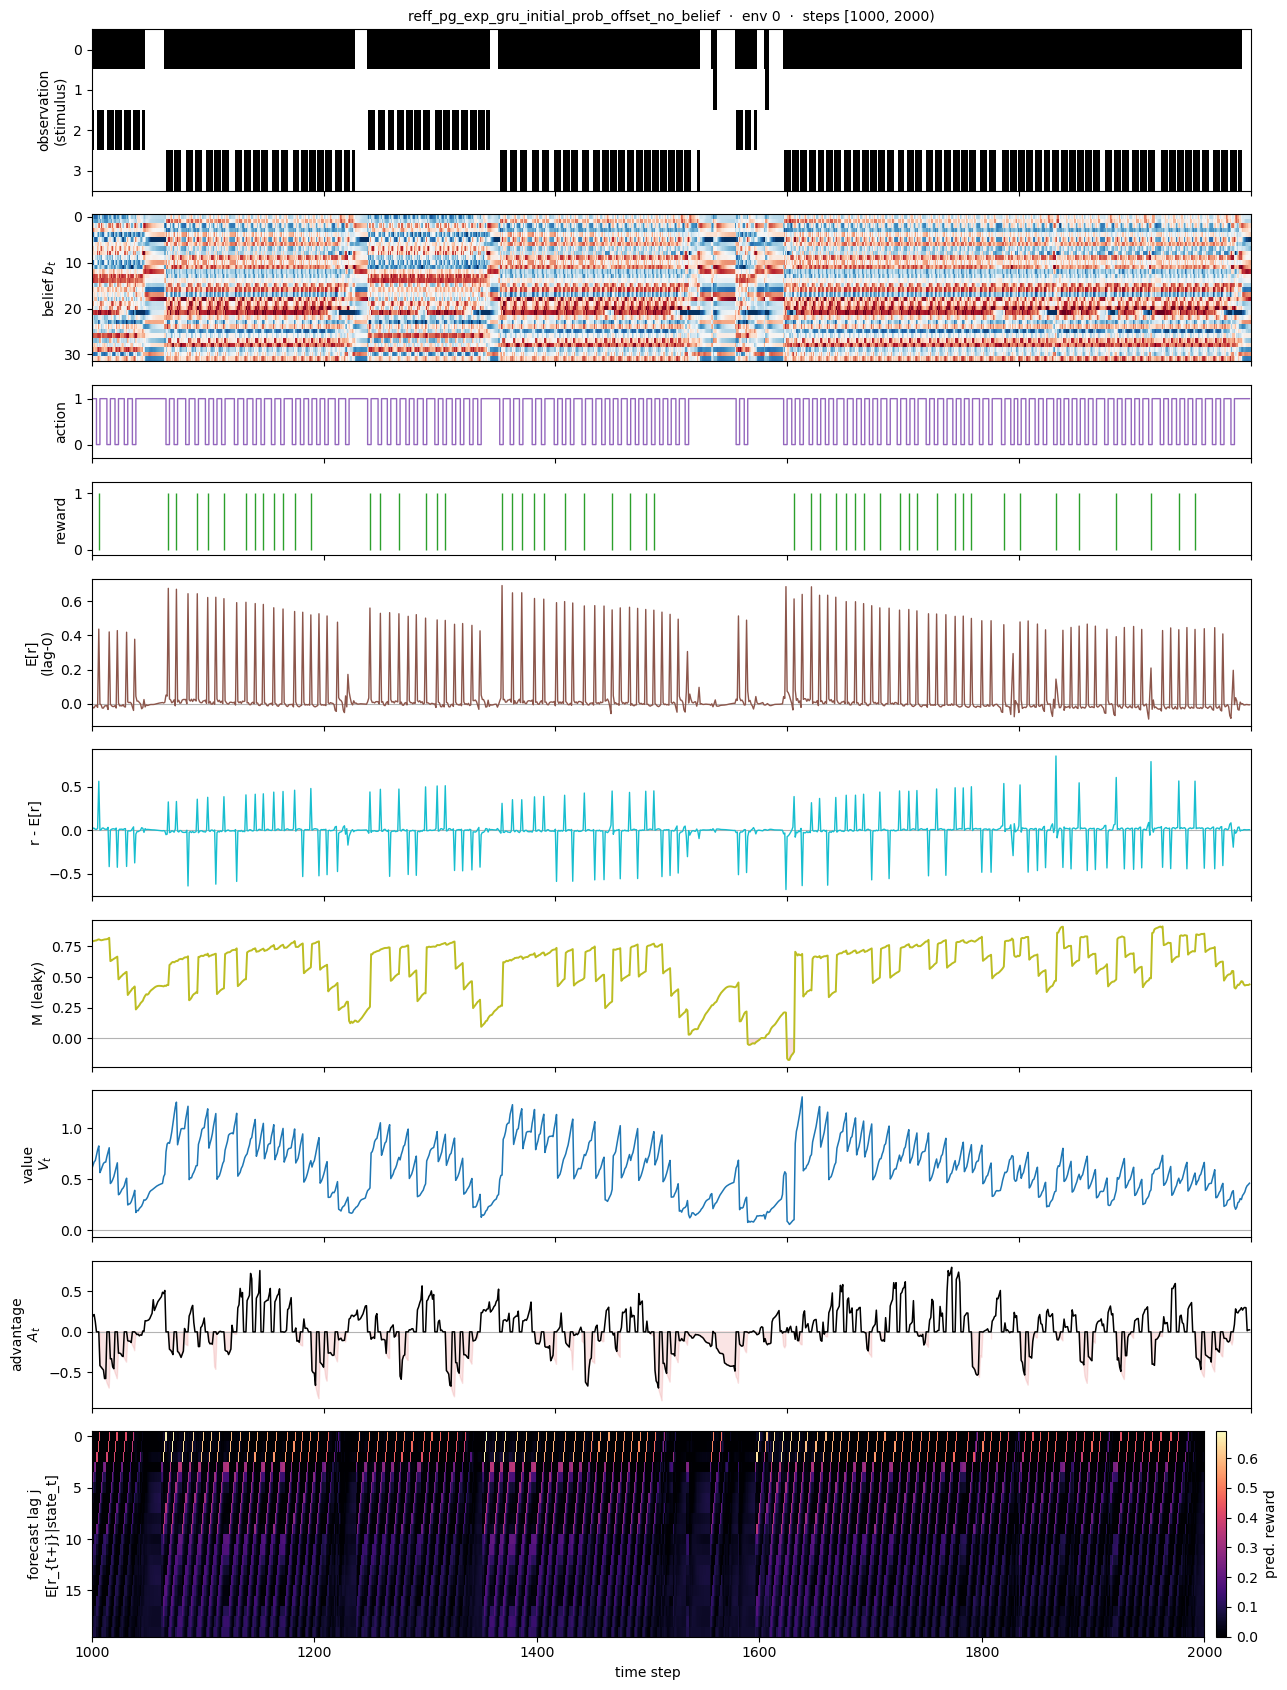

In [49]:
T0, T1 = 1000, min(2000, T)          # time window to plot
t = np.arange(T0, T1)

fig, ax = plt.subplots(10, 1, sharex=True, figsize=(13, 17),
                       gridspec_kw={'height_ratios': [1.1, 1.0, 0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.4]})

# 1) observations (stimulus x time)
ax[0].imshow(obs[T0:T1].T, aspect='auto', cmap='Greys', vmin=0, vmax=1,
             extent=[T0, T1, OBS - 0.5, -0.5], interpolation='nearest')
ax[0].set_yticks(range(OBS)); ax[0].set_ylabel('observation\n(stimulus)')

# 2) raw belief states b_t (belief dim x time)
if belief is not None:
    bvmax = float(np.percentile(np.abs(belief[T0:T1]), 99)) + 1e-8
    ax[1].imshow(belief[T0:T1].T, aspect='auto', cmap='RdBu_r', vmin=-bvmax, vmax=bvmax,
                 extent=[T0, T1, belief.shape[1] - 0.5, -0.5], interpolation='nearest')
else:
    ax[1].text(0.5, 0.5, 'no belief in this pickle', ha='center', va='center', transform=ax[1].transAxes)
ax[1].set_ylabel('belief $b_t$')

# 3) action
ax[2].step(t, actions[T0:T1], where='post', color='tab:purple', lw=1)
ax[2].set_yticks([0, 1]); ax[2].set_ylim(-0.3, 1.3); ax[2].set_ylabel('action')

# 4) reward (spikes)
ax[3].vlines(t[rewards[T0:T1] > 0], 0, 1, color='tab:green', lw=1)
ax[3].set_yticks([0, 1]); ax[3].set_ylim(-0.1, 1.2); ax[3].set_ylabel('reward')

# 5) expected reward E[r] (lag-0 forecast)
ax[4].axhline(0, color='0.7', lw=0.8)
ax[4].plot(t, exp_reward[T0:T1], color='tab:brown', lw=1)
ax[4].set_ylabel('E[r]\n(lag-0)')

# 6) reward - expected reward
ax[5].axhline(0, color='0.7', lw=0.8)
ax[5].plot(t, innov[T0:T1], color='tab:cyan', lw=1)
ax[5].set_ylabel('r - E[r]')

# 7) modulation M (leaky); M<0 => "overdue"
ax[6].axhline(0, color='0.7', lw=0.8)
ax[6].plot(t, M[T0:T1], color='tab:olive', lw=1.4)
ax[6].fill_between(t, M[T0:T1], 0, where=(M[T0:T1] < 0), color='tab:red', alpha=0.15)
ax[6].set_ylabel('M (leaky)')

# 8) critic value V_t
ax[7].axhline(0, color='0.7', lw=0.8)
ax[7].plot(t, V[T0:T1], color='tab:blue', lw=1.1)
ax[7].set_ylabel('value\n$V_t$')

# 9) per-timestep advantage A_t = M_t*G_t + gamma^K V_{t+K} - V_t
ax[8].axhline(0, color='0.7', lw=0.8)
ax[8].plot(t, advantage[T0:T1] * actions[T0:T1], color='k', lw=1.1)
ax[8].fill_between(t, advantage[T0:T1], 0, where=(advantage[T0:T1] < 0), color='tab:red', alpha=0.12)
ax[8].set_ylabel('advantage\n$A_t$')

# 10) multi-timestep forecast: r_hat[t, j] = E[r_{t+j} | state_t]
im = ax[9].imshow(r_hat[T0:T1].T, aspect='auto', cmap='magma', vmin=0,
                  extent=[T0, T1, r_hat.shape[1] - 0.5, -0.5], interpolation='nearest')
ax[9].set_ylabel('forecast lag j\nE[r_{t+j}|state_t]'); ax[9].set_xlabel('time step')
fig.colorbar(im, ax=ax[9], fraction=0.03, pad=0.01, label='pred. reward')

ax[0].set_title(f'{EXP}  ·  env {TRAJ_IDX}  ·  steps [{T0}, {T1})', fontsize=10)
plt.tight_layout()
plt.show()

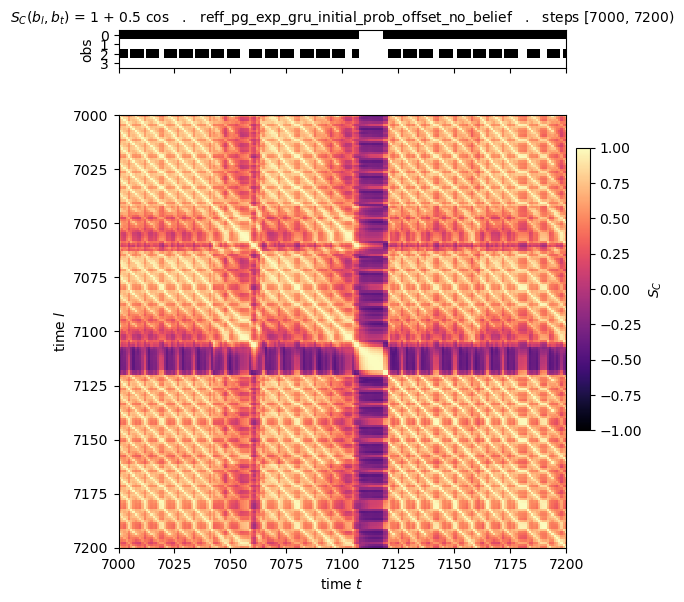

belief effective rank (entropy) 14.47 / 32  |  participation ratio 4.56  |  mean off-diagonal S_C 0.507  (1.5 = fully collapsed, ~1.0 = diverse)


In [38]:
# --- S_C similarity matrix (with an aligned observation strip) + belief effective rank -------------
# S_C(b_l, b_t) = 1 + 0.5 cos(b_l, b_t). Block structure = shared context; boundaries = where M stops
# carrying the old penalty (soft reset). The obs strip above shares the time axis so the S_C blocks can
# be read against patch/travel structure. Effective rank = how many directions the belief spans
# (~1 => collapsed, so S_C is ~constant and does no context-gating).
def belief_effective_rank(Bm):
    s = np.linalg.svd(Bm, compute_uv=False)                 # uncentered: collapse -> one dominant SV
    p = s / (s.sum() + 1e-12); p = p[p > 1e-12]
    erank = float(np.exp(-np.sum(p * np.log(p))))           # entropy-based effective rank (Roy & Vetterli)
    pr    = float((s**2).sum()**2 / ((s**2)**2).sum())      # participation ratio
    return erank, pr

T0b, T1b = 7000, 7200
if belief is None:
    print('no belief in this pickle -- retrain with the belief head to populate it')
else:
    bw = belief[T0b:T1b] # * exp_reward[T0b:T1b, None]
    bw = bw / (np.linalg.norm(bw, axis=1, keepdims=True) + 1e-8)
    Smat = (bw @ bw.T)                          # (W, W)  S_C in [0.5, 1.5]
    fig, (axo, axm) = plt.subplots(2, 1, sharex=True, figsize=(7.6 * 0.8, 8.4 * 0.8),
                                   gridspec_kw={'height_ratios': [0.7, 8]})
    # observations strip (aligned with the S_C time axis)
    axo.imshow(obs[T0b:T1b].T, aspect='auto', cmap='Greys', vmin=0, vmax=1,
               extent=[T0b, T1b, OBS - 0.5, -0.5], interpolation='nearest')
    axo.set_yticks(range(OBS)); axo.set_ylabel('obs')
    axo.set_title(f'$S_C(b_l, b_t)$ = 1 + 0.5 cos   .   {EXP}   .   steps [{T0b}, {T1b})', fontsize=10)
    # S_C matrix
    im = axm.imshow(Smat, origin='upper', extent=[T0b, T1b, T1b, T0b], cmap='magma',
                    vmin=-1, vmax=1, interpolation='nearest', aspect='auto')
    axm.set_xlabel('time $t$'); axm.set_ylabel('time $l$')
    fig.colorbar(im, ax=[axo, axm], fraction=0.03, pad=0.02, label='$S_C$')
    plt.show()
    erank, pr = belief_effective_rank(belief)
    offdiag = Smat[~np.eye(Smat.shape[0], dtype=bool)]
    print(f'belief effective rank (entropy) {erank:.2f} / {belief.shape[1]}  |  participation ratio {pr:.2f}'
          f'  |  mean off-diagonal S_C {offdiag.mean():.3f}  (1.5 = fully collapsed, ~1.0 = diverse)')

In [670]:
# (belief heatmap now lives in the main trace figure, right under the observations)